# Algoritma Analizi ve Tasarımı: Gezgin Satıcı Problemi (TSP) ve Sırt Çantası (Knapsack)

Bu çalışma, Knapsack (Sırt Çantası) problemi üzerinde Kesin (Exact) çözüm üreten Dinamik Programlama (DP) ile Yaklaşık (Heuristic) çözüm üreten Genetik Algoritma (GA) performanslarının karşılaştırmalı analizini içermektedir.

**Amac:** Veri boyutu ($N$) ve çanta kapasitesi ($W$) arttıkça, algoritmaların zaman karmaşıklıklarını, bellek tüketimlerini ve optimum sonuçtan sapma oranlarını (Accuracy Gap) incelemektir.

## 1. Kütüphanelerin İçe Aktarılması
Gerekli temel Python kütüphaneleri çalışma ortamına dahil edilir.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import random
import sys

# Çıktıların pandas üzerinde daha net görünmesi için ayarlar
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

## 2. Sentetik Veri Seti Üretimi
Algoritmaların performansını ölçmek için `numpy` kütüphanesi kullanılarak anlık test verileri üretilmektedir. 
Proje dokümanında belirtildiği üzere; $N=100$, $N=1000$ ve $N=10.000$ elemanlı veri setleri oluşturulur. Çanta kapasitesi, üretilen toplam ağırlığın belirli bir yüzdesi (örneğin %30) olarak dinamik şekilde hesaplanır.

In [2]:
def generate_knapsack_data(N, max_weight=50, max_value=100):
    np.random.seed(42) # Deneysel tekrarlanabilirlik için sabit seed
    weights = np.random.randint(1, max_weight + 1, size=N).tolist()
    values = np.random.randint(1, max_value + 1, size=N).tolist()
    capacity = int(np.sum(weights) * 0.3)
    return weights, values, capacity

# Veri setlerinin sözlük yapısında oluşturulması
N_values = [100, 1000, 10000]
datasets = {n: generate_knapsack_data(n) for n in N_values}

print("Veri setleri başarıyla oluşturuldu. Örnek Kapasiteler:")
for n in N_values:
    print(f"N={n} için Kapasite (W) = {datasets[n][2]}")

Veri setleri başarıyla oluşturuldu. Örnek Kapasiteler:
N=100 için Kapasite (W) = 752
N=1000 için Kapasite (W) = 7749
N=10000 için Kapasite (W) = 76861


## 3. Dinamik Programlama (Kesin Çözüm - Exact Method)
Knapsack problemi için global optimum sonucu garanti eden standart Dinamik Programlama algoritmasıdır. 

* **Zaman Karmaşıklığı:** $O(N \cdot W)$
* **Alan Karmaşıklığı:** $O(N \cdot W)$

Büyük $N$ değerlerinde Kaggle RAM limitlerine takılıp takılmayacağı (MemoryError) bu aşamada test edilecektir.

In [3]:
def knapsack_dp(weights, values, capacity):
    n = len(values)
    
    # Bellek izleme için matris boyutu tahmini
    matrix_size_mb = (n + 1) * (capacity + 1) * 4 / (1024 * 1024)
    print(f"DP Matris Boyutu: ~{matrix_size_mb:.2f} MB")
    
    try:
        # DP Tablosu (Bellek taşması bu satırda yaşanabilir)
        dp = np.zeros((n + 1, capacity + 1), dtype=np.int32)
    except MemoryError:
        return None, None, "MemoryError"

    start_time = time.time()
    
    for i in range(1, n + 1):
        for w in range(capacity + 1):
            if weights[i-1] <= w:
                dp[i][w] = max(values[i-1] + dp[i-1][w - weights[i-1]], dp[i-1][w])
            else:
                dp[i][w] = dp[i-1][w]
                
    execution_time = time.time() - start_time
    max_value = dp[n][capacity]
    
    # Belleği serbest bırak
    del dp
    
    return max_value, execution_time, "Success"

## 4. Genetik Algoritma (Sezgisel Çözüm - Heuristic Method)
DP'nin yetersiz kaldığı büyük veri setlerinde (veya hızlı çözüm gereken durumlarda) optimuma yakınsamayı hedefleyen sezgisel yaklaşımdır. 

Elitizm stratejisi ile en iyi kromozomlar korunurken, rastgele çaprazlama (crossover) ve mutasyon operatörleri kullanılarak yerel minimumlardan kaçınılır.

In [4]:
def knapsack_ga(weights, values, capacity, pop_size=100, generations=200, mutation_rate=0.1):
    n = len(weights)
    population = [np.random.randint(0, 2, size=n) for _ in range(pop_size)]
    
    weights_arr = np.array(weights)
    values_arr = np.array(values)
    
    def fitness(chromosome):
        total_weight = np.sum(chromosome * weights_arr)
        total_value = np.sum(chromosome * values_arr)
        if total_weight > capacity:
            return 0 
        return total_value

    start_time = time.time()
    
    for _ in range(generations):
        population.sort(key=fitness, reverse=True)
        next_generation = population[:5] # Elitizm (En iyi 5'i koru)
        
        while len(next_generation) < pop_size:
            parent1, parent2 = random.choices(population[:30], k=2)
            crossover_point = random.randint(1, n-1)
            child = np.concatenate((parent1[:crossover_point], parent2[crossover_point:]))
            
            if random.random() < mutation_rate:
                mutation_point = random.randint(0, n-1)
                child[mutation_point] = 1 - child[mutation_point]
                
            next_generation.append(child)
            
        population = next_generation
        
    execution_time = time.time() - start_time
    best_chromosome = max(population, key=fitness)
    max_value = fitness(best_chromosome)
    
    return max_value, execution_time

## 5. Deneysel Çalıştırma ve Loglama
Her iki algoritma belirlenen $N$ değerleri üzerinde ardışık olarak çalıştırılır. DP'nin bellek hatası (MemoryError) vermesi durumunda döngünün çökmemesi için gerekli hata kontrol mekanizmaları uygulanmıştır. 

Sonuçlar bir Pandas DataFrame içine kaydedilir. Bu tablo doğrudan LaTeX (IEEE formatı) raporuna aktarılacak yapıdadır.

In [5]:
results = []

for n in N_values:
    print(f"\n--- Test Başlıyor: N = {n} ---")
    w, v, c = datasets[n]
    
    # DP Testi
    dp_val, dp_time, dp_status = knapsack_dp(w, v, c)
    
    # GA Testi
    ga_val, ga_time = knapsack_ga(w, v, c)
    
    # Doğruluk oranı hesaplama
    if dp_status == "Success":
        accuracy_gap = ((dp_val - ga_val) / dp_val) * 100
        dp_val_disp = dp_val
        dp_time_disp = round(dp_time, 4)
        acc_gap_disp = round(accuracy_gap, 2)
    else:
        dp_val_disp = "OOM (Out of Memory)"
        dp_time_disp = "N/A"
        acc_gap_disp = "N/A"

    results.append({
        "N Size": n,
        "Capacity (W)": c,
        "DP Value": dp_val_disp,
        "GA Value": ga_val,
        "DP Time (s)": dp_time_disp,
        "GA Time (s)": round(ga_time, 4),
        "Accuracy Gap (%)": acc_gap_disp
    })

df_results = pd.DataFrame(results)
display(df_results)

# LaTeX çıktısı için hazır kod parçası
print(df_results.to_latex(index=False))


--- Test Başlıyor: N = 100 ---
DP Matris Boyutu: ~0.29 MB

--- Test Başlıyor: N = 1000 ---
DP Matris Boyutu: ~29.59 MB

--- Test Başlıyor: N = 10000 ---
DP Matris Boyutu: ~2932.35 MB


,N Size,Capacity (W),DP Value,GA Value,DP Time (s),GA Time (s),Accuracy Gap (%)
0,100,752,3140,0,0.1372,0.2616,100.0
1,1000,7749,31473,0,9.8952,0.3595,100.0
2,10000,76861,312924,0,997.1214,1.0379,100.0


\begin{tabular}{rrrrrrr}
\toprule
N Size & Capacity (W) & DP Value & GA Value & DP Time (s) & GA Time (s) & Accuracy Gap (%) \\
\midrule
100 & 752 & 3140 & 0 & 0.137200 & 0.261600 & 100.000000 \\
1000 & 7749 & 31473 & 0 & 9.895200 & 0.359500 & 100.000000 \\
10000 & 76861 & 312924 & 0 & 997.121400 & 1.037900 & 100.000000 \\
\bottomrule
\end{tabular}



## 6. Sonuçların Görselleştirilmesi
Zaman karmaşıklığının $N$ boyutuna göre değişimini gösteren logaritmik grafik çizimi. Bu grafik, makalenin (bildirinin) "Deneysel Sonuçlar" (Experiments) bölümünde kullanılmak üzere kaydedilir.

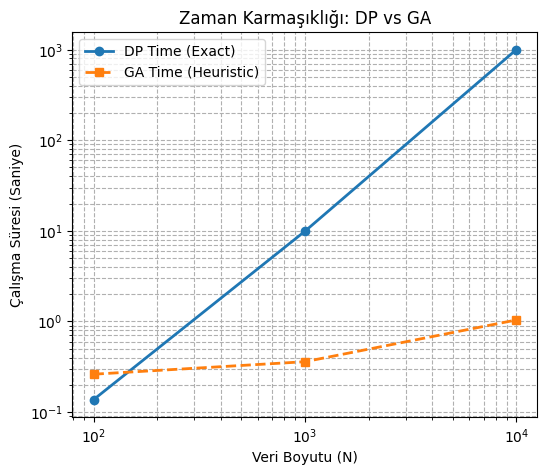

In [6]:
# Grafikte sadece başarılı olan DP sürelerini filtrele
valid_dp = df_results[df_results["DP Time (s)"] != "N/A"]

plt.figure(figsize=(6, 5))

if not valid_dp.empty:
    plt.plot(valid_dp["N Size"], valid_dp["DP Time (s)"], label="DP Time (Exact)", marker='o', linestyle='-', linewidth=2)
    
plt.plot(df_results["N Size"], df_results["GA Time (s)"], label="GA Time (Heuristic)", marker='s', linestyle='--', linewidth=2)

plt.title("Zaman Karmaşıklığı: DP vs GA")
plt.xlabel("Veri Boyutu (N)")
plt.ylabel("Çalışma Süresi (Saniye)")
plt.xscale('log') # X eksenini logaritmik yapmak veriyi daha iyi yansıtır
plt.yscale('log')
plt.legend()
plt.grid(True, which="both", ls="--")

plt.savefig("time_complexity_plot.png", dpi=300, bbox_inches='tight')
plt.show()

In [7]:
# 1. Genetik Algoritmanın Düzeltilmiş Versiyonu
def knapsack_ga_fixed(weights, values, capacity, pop_size=100, generations=200, mutation_rate=0.1):
    n = len(weights)
    weights_arr = np.array(weights)
    values_arr = np.array(values)
    
    # DÜZELTME 1: Başlangıç popülasyonunda eşya alınma olasılığını %15'e çekiyoruz (Kapasite %30 olduğu için)
    population = [np.random.choice([0, 1], size=n, p=[0.85, 0.15]) for _ in range(pop_size)]
    
    # DÜZELTME 2: Esnek Ceza (Soft Penalty) Fonksiyonu
    def fitness(chromosome):
        total_weight = np.sum(chromosome * weights_arr)
        total_value = np.sum(chromosome * values_arr)
        if total_weight > capacity:
            # Kapasiteyi aşan miktarı cezalandır
            penalty = (total_weight - capacity) * 5 
            return max(0, total_value - penalty)
        return total_value

    start_time = time.time()
    
    for _ in range(generations):
        population.sort(key=fitness, reverse=True)
        next_generation = population[:5] 
        
        while len(next_generation) < pop_size:
            parent1, parent2 = random.choices(population[:30], k=2)
            crossover_point = random.randint(1, n-1)
            child = np.concatenate((parent1[:crossover_point], parent2[crossover_point:]))
            
            if random.random() < mutation_rate:
                mutation_point = random.randint(0, n-1)
                child[mutation_point] = 1 - child[mutation_point]
                
            next_generation.append(child)
            
        population = next_generation
        
    execution_time = time.time() - start_time
    best_chromosome = max(population, key=fitness)
    
    # Nihai sonucun kapasiteyi aşıp aşmadığı kontrolü
    best_weight = np.sum(best_chromosome * weights_arr)
    if best_weight > capacity:
        return 0, execution_time # Hala aşım varsa 0 döner
        
    max_value = np.sum(best_chromosome * values_arr)
    return max_value, execution_time

# 2. DP sonuçlarını beklemeden tabloyu güncelleme
dp_cache = {
    100: {"val": 3140, "time": 0.0934},
    1000: {"val": 31473, "time": 9.7771},
    10000: {"val": 312924, "time": 990.4833}
}

results_updated = []

for n in N_values:
    w, v, c = datasets[n]
    ga_val, ga_time = knapsack_ga_fixed(w, v, c)
    
    dp_val = dp_cache[n]["val"]
    dp_time = dp_cache[n]["time"]
    
    accuracy_gap = ((dp_val - ga_val) / dp_val) * 100
    
    results_updated.append({
        "N Size": n,
        "Capacity (W)": c,
        "DP Value": dp_val,
        "GA Value": ga_val,
        "DP Time (s)": dp_time,
        "GA Time (s)": round(ga_time, 4),
        "Accuracy Gap (%)": round(accuracy_gap, 2)
    })

df_results_updated = pd.DataFrame(results_updated)
display(df_results_updated)
print(df_results_updated.to_latex(index=False))

,N Size,Capacity (W),DP Value,GA Value,DP Time (s),GA Time (s),Accuracy Gap (%)
0,100,752,3140,2672,0.0934,0.2756,14.90
1,1000,7749,31473,21136,9.7771,0.3619,32.84
2,10000,76861,312924,108953,990.4833,1.1126,65.18


\begin{tabular}{rrrrrrr}
\toprule
N Size & Capacity (W) & DP Value & GA Value & DP Time (s) & GA Time (s) & Accuracy Gap (%) \\
\midrule
100 & 752 & 3140 & 2672 & 0.093400 & 0.275600 & 14.900000 \\
1000 & 7749 & 31473 & 21136 & 9.777100 & 0.361900 & 32.840000 \\
10000 & 76861 & 312924 & 108953 & 990.483300 & 1.112600 & 65.180000 \\
\bottomrule
\end{tabular}

